<a href="https://colab.research.google.com/github/satvik959/DL-2025-26/blob/main/WEEK7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cuda
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Epoch [1/1]
Train Loss: 0.8691 | Train Acc: 74.94%
Test  Loss: 0.5324 | Test  Acc: 83.61%
--------------------------------------------------


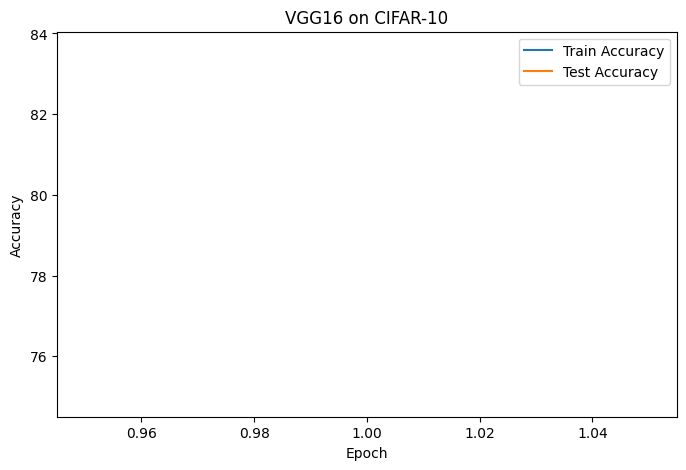

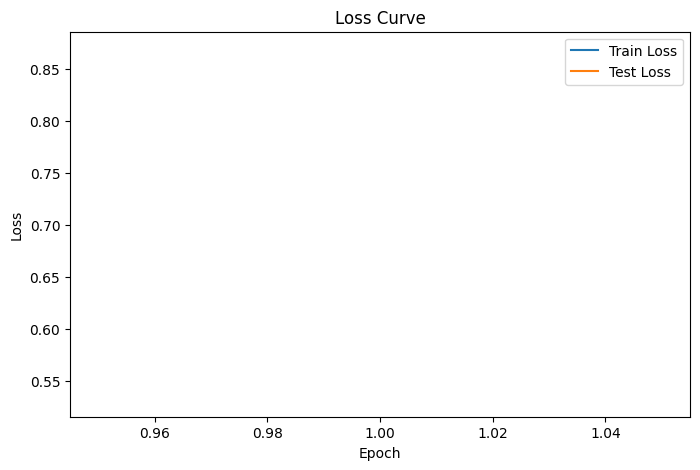

Model saved as vgg16_cifar10.pth


In [2]:
#
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ----------------------------
# 1. Data transforms
# ----------------------------
# CIFAR-10 images are 32x32, but pretrained VGG expects ImageNet-style input size.
# So we resize them to 224x224 and normalize with ImageNet mean/std.

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ----------------------------
# 2. Load dataset
# ----------------------------
train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

class_names = train_dataset.classes
print("Classes:", class_names)

# ----------------------------
# 3. Load pretrained VGG16
# ----------------------------
weights = models.VGG16_Weights.DEFAULT
model = models.vgg16(weights=weights)

# Freeze feature extractor first
for param in model.features.parameters():
    param.requires_grad = False

# Replace final classifier layer for CIFAR-10 (10 classes)
in_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(in_features, 10)

model = model.to(device)

# ----------------------------
# 4. Loss and optimizer
# ----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

# ----------------------------
# 5. Training function
# ----------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

# ----------------------------
# 6. Evaluation function
# ----------------------------
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

# ----------------------------
# 7. Train for a few epochs
# ----------------------------
num_epochs = 1
train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.2f}%")
    print("-" * 50)

# ----------------------------
# 8. Plot accuracy and loss
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_accs, label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), test_accs, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG16 on CIFAR-10")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs + 1), test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

# ----------------------------
# 9. Save model
# ----------------------------
torch.save(model.state_dict(), "vgg16_cifar10.pth")
print("Model saved as vgg16_cifar10.pth")

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_train = datasets.ImageFolder("intel_dataset/seg_train", transform=train_transform)
full_test = datasets.ImageFolder("intel_dataset/seg_test", transform=test_transform)

# smaller subset for faster training first
train_dataset = Subset(full_train, range(min(4000, len(full_train))))
test_dataset = Subset(full_test, range(min(1000, len(full_test))))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

weights = models.VGG16_Weights.DEFAULT
model = models.vgg16(weights=weights)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[6] = nn.Linear(model.classifier[6].in_features, 6)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

def train_one_epoch():
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()

    return total_loss / total, 100 * correct / total

def evaluate():
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()

    return total_loss / total, 100 * correct / total

for epoch in range(2):
    train_loss, train_acc = train_one_epoch()
    test_loss, test_acc = evaluate()

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.2f}%")
    print("-" * 50)

Using device: cpu


FileNotFoundError: [Errno 2] No such file or directory: 'intel_dataset/seg_train'

In [6]:
import os

print("Current folder:", os.getcwd())
print("seg_train exists:", os.path.exists("intel_dataset/seg_train"))
print("seg_test exists:", os.path.exists("intel_dataset/seg_test"))

Current folder: /content
seg_train exists: False
seg_test exists: False


In [7]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms

print("Current working directory:", os.getcwd())

train_path = "intel_dataset/seg_train"
test_path = "intel_dataset/seg_test"

print("Train path exists:", os.path.exists(train_path))
print("Test path exists:", os.path.exists(test_path))

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_train = datasets.ImageFolder(train_path, transform=train_transform)
full_test = datasets.ImageFolder(test_path, transform=test_transform)

print("Classes:", full_train.classes)
print("Train size:", len(full_train))
print("Test size:", len(full_test))

train_dataset = Subset(full_train, range(min(2000, len(full_train))))
test_dataset = Subset(full_test, range(min(500, len(full_test))))

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

try:
    weights = models.VGG16_Weights.DEFAULT
    model = models.vgg16(weights=weights)
except Exception as e:
    print("Pretrained weights could not be loaded:", e)
    print("Loading model without pretrained weights...")
    model = models.vgg16(weights=None)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[6] = nn.Linear(model.classifier[6].in_features, len(full_train.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

def train_one_epoch():
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()

    return total_loss / total, 100 * correct / total

def evaluate():
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()

    return total_loss / total, 100 * correct / total

for epoch in range(1):
    train_loss, train_acc = train_one_epoch()
    test_loss, test_acc = evaluate()

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.2f}%")
    print("-" * 50)

Current working directory: /content
Train path exists: False
Test path exists: False
Using device: cpu


FileNotFoundError: [Errno 2] No such file or directory: 'intel_dataset/seg_train'

In [8]:
archive.zip

NameError: name 'archive' is not defined

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

weights = models.VGG16_Weights.DEFAULT
model = models.vgg16(weights=weights)

for param in model.features.parameters():
    param.requires_grad = False

for param in model.features[24:].parameters():
    param.requires_grad = True

model.classifier[6] = nn.Linear(model.classifier[6].in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, pred = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()

    return total_loss / total, 100 * correct / total

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()

    return total_loss / total, 100 * correct / total

num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.2f}%")
    print("-" * 50)

Using device: cuda
Epoch [1/5]
Train Loss: 0.5266 | Train Acc: 81.88%
Test  Loss: 0.3272 | Test  Acc: 89.12%
--------------------------------------------------
Epoch [2/5]
Train Loss: 0.3025 | Train Acc: 89.60%
Test  Loss: 0.3043 | Test  Acc: 89.94%
--------------------------------------------------
Epoch [3/5]
Train Loss: 0.2279 | Train Acc: 92.14%
Test  Loss: 0.3439 | Test  Acc: 89.49%
--------------------------------------------------
Epoch [4/5]
Train Loss: 0.1837 | Train Acc: 93.73%
Test  Loss: 0.2664 | Test  Acc: 91.83%
--------------------------------------------------
Epoch [5/5]
Train Loss: 0.1476 | Train Acc: 94.92%
Test  Loss: 0.2729 | Test  Acc: 91.76%
--------------------------------------------------


In [11]:
class AlexNetSmall(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNetSmall, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

alex_model = AlexNetSmall(num_classes=10)
alex_results = train_model(alex_model, train_loader_alex, test_loader_alex, epochs=1, lr=0.0002)

NameError: name 'train_model' is not defined

In [12]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------
# LeNet dataset (32x32)
# ---------------------------
train_transform_lenet = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

test_transform_lenet = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset_lenet = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform_lenet)
test_dataset_lenet = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform_lenet)

train_loader_lenet = DataLoader(train_dataset_lenet, batch_size=64, shuffle=True, num_workers=2)
test_loader_lenet = DataLoader(test_dataset_lenet, batch_size=64, shuffle=False, num_workers=2)

# ---------------------------
# AlexNet / ZF-Net dataset (64x64)
# ---------------------------
train_transform_big = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

test_transform_big = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset_big = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform_big)
test_dataset_big = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform_big)

train_loader_big = DataLoader(train_dataset_big, batch_size=64, shuffle=True, num_workers=2)
test_loader_big = DataLoader(test_dataset_big, batch_size=64, shuffle=False, num_workers=2)

classes = train_dataset_lenet.classes
print("Classes:", classes)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model(model, train_loader, test_loader, epochs=1, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_acc = 100 * correct / total
        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss/total:.4f} | Train Acc: {train_acc:.2f}%")

    total_time = time.time() - start_time

    y_true = []
    y_pred = []

    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    print("\nTest Metrics")
    print("Accuracy :", round(acc * 100, 2), "%")
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("Training Time:", round(total_time, 2), "seconds")
    print("Trainable Parameters:", count_parameters(model))
    print("-" * 60)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "time": total_time,
        "params": count_parameters(model),
        "cm": cm
    }

Using device: cuda
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [13]:
class AlexNetSmall(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNetSmall, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

alex_model = AlexNetSmall(num_classes=10)
alex_results = train_model(alex_model, train_loader_big, test_loader_big, epochs=1, lr=0.0002)

Epoch 1/1 | Loss: 1.6193 | Train Acc: 39.71%

Test Metrics
Accuracy : 54.94 %
Precision: 0.541
Recall   : 0.5494
F1-score : 0.5373
Training Time: 38.4 seconds
Trainable Parameters: 19562826
------------------------------------------------------------


In [14]:
class ZFNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ZFNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=7, stride=2, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, stride=2, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 2))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

zf_model = ZFNet(num_classes=10)
zf_results = train_model(zf_model, train_loader_big, test_loader_big, epochs=1, lr=0.0002)

Epoch 1/1 | Loss: 1.7156 | Train Acc: 33.93%

Test Metrics
Accuracy : 47.35 %
Precision: 0.4907
Recall   : 0.4735
F1-score : 0.4516
Training Time: 25.12 seconds
Trainable Parameters: 4256394
------------------------------------------------------------


In [15]:
class BasicConv(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(BasicConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class InceptionBlock(nn.Module):
    def __init__(self, in_channels, c1, c3red, c3, c5red, c5, pool_proj):
        super(InceptionBlock, self).__init__()

        self.branch1 = BasicConv(in_channels, c1, kernel_size=1)

        self.branch2 = nn.Sequential(
            BasicConv(in_channels, c3red, kernel_size=1),
            BasicConv(c3red, c3, kernel_size=3, padding=1)
        )

        self.branch3 = nn.Sequential(
            BasicConv(in_channels, c5red, kernel_size=1),
            BasicConv(c5red, c5, kernel_size=5, padding=2)
        )

        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            BasicConv(in_channels, pool_proj, kernel_size=1)
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        return torch.cat([b1, b2, b3, b4], 1)

class MiniGoogLeNet(nn.Module):
    def __init__(self, num_classes=10):
        super(MiniGoogLeNet, self).__init__()

        self.pre_layers = nn.Sequential(
            BasicConv(3, 64, kernel_size=3, padding=1),
            BasicConv(64, 128, kernel_size=3, padding=1),
            nn.MaxPool2d(2, 2)
        )

        self.inception1 = InceptionBlock(128, 32, 48, 64, 8, 16, 16)
        self.inception2 = InceptionBlock(128, 64, 64, 96, 16, 32, 32)

        self.pool = nn.MaxPool2d(2, 2)

        self.inception3 = InceptionBlock(224, 96, 64, 96, 16, 48, 32)
        self.inception4 = InceptionBlock(272, 128, 96, 128, 32, 64, 64)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(384, num_classes)

    def forward(self, x):
        x = self.pre_layers(x)
        x = self.inception1(x)
        x = self.inception2(x)
        x = self.pool(x)
        x = self.inception3(x)
        x = self.inception4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

google_model = MiniGoogLeNet(num_classes=10)
google_results = train_model(google_model, train_loader_big, test_loader_big, epochs=1, lr=0.0005)

Epoch 1/1 | Loss: 1.3072 | Train Acc: 52.48%

Test Metrics
Accuracy : 58.24 %
Precision: 0.6545
Recall   : 0.5824
F1-score : 0.5894
Training Time: 71.13 seconds
Trainable Parameters: 587098
------------------------------------------------------------


In [16]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out


class SmallResNet(nn.Module):
    def __init__(self, num_classes=10):
        super(SmallResNet, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.layer1 = self._make_layer(64, 64, blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, blocks, stride):
        layers = [ResidualBlock(in_channels, out_channels, stride)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


resnet_model = SmallResNet(num_classes=10)
resnet_results = train_model(resnet_model, train_loader_big, test_loader_big, epochs=1, lr=0.0005)

Epoch 1/1 | Loss: 1.3343 | Train Acc: 51.32%

Test Metrics
Accuracy : 58.0 %
Precision: 0.6233
Recall   : 0.58
F1-score : 0.5636
Training Time: 150.58 seconds
Trainable Parameters: 11173962
------------------------------------------------------------


In [17]:
print("\nFINAL COMPARISON")
print(f"LeNet      -> Accuracy: {lenet_results['accuracy']*100:.2f}% | Precision: {lenet_results['precision']:.4f} | Recall: {lenet_results['recall']:.4f} | F1: {lenet_results['f1']:.4f} | Time: {lenet_results['time']:.2f}s | Params: {lenet_results['params']}")
print(f"AlexNet    -> Accuracy: {alex_results['accuracy']*100:.2f}% | Precision: {alex_results['precision']:.4f} | Recall: {alex_results['recall']:.4f} | F1: {alex_results['f1']:.4f} | Time: {alex_results['time']:.2f}s | Params: {alex_results['params']}")
print(f"ZF-Net     -> Accuracy: {zf_results['accuracy']*100:.2f}% | Precision: {zf_results['precision']:.4f} | Recall: {zf_results['recall']:.4f} | F1: {zf_results['f1']:.4f} | Time: {zf_results['time']:.2f}s | Params: {zf_results['params']}")
print(f"GoogLeNet  -> Accuracy: {google_results['accuracy']*100:.2f}% | Precision: {google_results['precision']:.4f} | Recall: {google_results['recall']:.4f} | F1: {google_results['f1']:.4f} | Time: {google_results['time']:.2f}s | Params: {google_results['params']}")
print(f"ResNet     -> Accuracy: {resnet_results['accuracy']*100:.2f}% | Precision: {resnet_results['precision']:.4f} | Recall: {resnet_results['recall']:.4f} | F1: {resnet_results['f1']:.4f} | Time: {resnet_results['time']:.2f}s | Params: {resnet_results['params']}")


FINAL COMPARISON


NameError: name 'lenet_results' is not defined

In [18]:
print("\nFINAL COMPARISON")

if 'lenet_results' in globals():
    print(f"LeNet      -> Accuracy: {lenet_results['accuracy']*100:.2f}% | Precision: {lenet_results['precision']:.4f} | Recall: {lenet_results['recall']:.4f} | F1: {lenet_results['f1']:.4f} | Time: {lenet_results['time']:.2f}s | Params: {lenet_results['params']}")
else:
    print("LeNet      -> Not run yet")

if 'alex_results' in globals():
    print(f"AlexNet    -> Accuracy: {alex_results['accuracy']*100:.2f}% | Precision: {alex_results['precision']:.4f} | Recall: {alex_results['recall']:.4f} | F1: {alex_results['f1']:.4f} | Time: {alex_results['time']:.2f}s | Params: {alex_results['params']}")
else:
    print("AlexNet    -> Not run yet")

if 'zf_results' in globals():
    print(f"ZF-Net     -> Accuracy: {zf_results['accuracy']*100:.2f}% | Precision: {zf_results['precision']:.4f} | Recall: {zf_results['recall']:.4f} | F1: {zf_results['f1']:.4f} | Time: {zf_results['time']:.2f}s | Params: {zf_results['params']}")
else:
    print("ZF-Net     -> Not run yet")

if 'google_results' in globals():
    print(f"GoogLeNet  -> Accuracy: {google_results['accuracy']*100:.2f}% | Precision: {google_results['precision']:.4f} | Recall: {google_results['recall']:.4f} | F1: {google_results['f1']:.4f} | Time: {google_results['time']:.2f}s | Params: {google_results['params']}")
else:
    print("GoogLeNet  -> Not run yet")

if 'resnet_results' in globals():
    print(f"ResNet     -> Accuracy: {resnet_results['accuracy']*100:.2f}% | Precision: {resnet_results['precision']:.4f} | Recall: {resnet_results['recall']:.4f} | F1: {resnet_results['f1']:.4f} | Time: {resnet_results['time']:.2f}s | Params: {resnet_results['params']}")
else:
    print("ResNet     -> Not run yet")


FINAL COMPARISON
LeNet      -> Not run yet
AlexNet    -> Accuracy: 54.94% | Precision: 0.5410 | Recall: 0.5494 | F1: 0.5373 | Time: 38.40s | Params: 19562826
ZF-Net     -> Accuracy: 47.35% | Precision: 0.4907 | Recall: 0.4735 | F1: 0.4516 | Time: 25.12s | Params: 4256394
GoogLeNet  -> Accuracy: 58.24% | Precision: 0.6545 | Recall: 0.5824 | F1: 0.5894 | Time: 71.13s | Params: 587098
ResNet     -> Accuracy: 58.00% | Precision: 0.6233 | Recall: 0.5800 | F1: 0.5636 | Time: 150.58s | Params: 11173962


In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out


class SmallResNet(nn.Module):
    def __init__(self, num_classes=10):
        super(SmallResNet, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.layer1 = self._make_layer(64, 64, blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, blocks=2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, blocks, stride):
        layers = [ResidualBlock(in_channels, out_channels, stride)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


resnet_model = SmallResNet(num_classes=10)
resnet_results = train_model(resnet_model, train_loader_big, test_loader_big, epochs=2, lr=0.0005)